# CatBoost — A Beginner-Friendly Learning Notebook

This notebook teaches **CatBoost classification** through a complete project containing both numerical and categorical features.

We will:

1. Understand CatBoost in plain language.
2. Create a realistic synthetic customer-churn dataset.
3. Keep categorical columns as text instead of manually one-hot encoding them.
4. Create separate **training, validation, and test** sets.
5. Train a `CatBoostClassifier` with early stopping.
6. Retrain the final model using the selected number of trees.
7. Evaluate once on the untouched test set.
8. Explain every model and fit parameter used in simple language.
9. Inspect learning curves, probabilities, and feature importance.
10. Save and reload the trained model.

The dataset is generated inside the notebook, so no download is required.

## 1. What is CatBoost?

**CatBoost** means **Categorical Boosting**.

Like other gradient-boosting libraries, CatBoost builds decision trees one after another. Every new tree tries to improve the current ensemble.

Its major practical advantage is categorical data handling. A column can contain values such as:

```text
contract_type = Month-to-month, One year, Two year
payment_method = UPI, Credit card, Cash
```

CatBoost can receive these values directly when we identify the categorical columns through `cat_features`.

This reduces manual preprocessing and avoids treating arbitrary category codes as meaningful numeric quantities.

## 2. Why use training, validation, and test sets?

| Dataset | Used for | Simple meaning |
|---|---|---|
| **Training set** | Learn tree rules and category statistics | The model studies this data. |
| **Validation set** | Early stopping and model choices | A practice exam. |
| **Test set** | One final unbiased evaluation | The final exam. |

We use approximately:

- **70% training**
- **15% validation**
- **15% test**

The test set stays untouched until the final model is ready.

## 3. Install packages

In [1]:
# %pip install -q catboost scikit-learn pandas numpy matplotlib

## 4. Imports and reproducibility

In [2]:
import warnings
from pathlib import Path

import catboost
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn

from catboost import CatBoostClassifier
from IPython.display import display
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    f1_score,
    log_loss,
    precision_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay,
)
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
RANDOM_STATE = 42

print('CatBoost version:', catboost.__version__)
print('scikit-learn version:', sklearn.__version__)

CatBoost version: 1.2.8
scikit-learn version: 1.8.0


### Why `random_seed=42` and `random_state=42`?

CatBoost names its main seed `random_seed`; scikit-learn's split function uses `random_state`. A fixed value makes the workflow repeatable.

## 5. Create a mixed numerical + categorical dataset

In [3]:
rng = np.random.default_rng(RANDOM_STATE)
number_of_rows = 1500

customer_data = pd.DataFrame({
    'city': rng.choice(
        ['Delhi', 'Mumbai', 'Bengaluru', 'Pune', 'Hyderabad'],
        size=number_of_rows,
        p=[0.22, 0.20, 0.24, 0.16, 0.18],
    ),
    'contract_type': rng.choice(
        ['Month-to-month', 'One year', 'Two year'],
        size=number_of_rows,
        p=[0.55, 0.28, 0.17],
    ),
    'payment_method': rng.choice(
        ['UPI', 'Credit card', 'Bank transfer', 'Cash'],
        size=number_of_rows,
        p=[0.35, 0.28, 0.25, 0.12],
    ),
    'device_type': rng.choice(
        ['Android', 'iOS', 'Web'],
        size=number_of_rows,
        p=[0.58, 0.25, 0.17],
    ),
    'support_plan': rng.choice(
        ['None', 'Basic', 'Premium'],
        size=number_of_rows,
        p=[0.34, 0.45, 0.21],
    ),
    'tenure_months': rng.integers(1, 73, size=number_of_rows),
    'monthly_spend': np.clip(rng.normal(65, 20, size=number_of_rows), 15, 140),
    'support_calls': rng.poisson(1.4, size=number_of_rows),
    'late_payments': rng.binomial(4, 0.15, size=number_of_rows),
    'usage_hours': np.clip(rng.normal(45, 18, size=number_of_rows), 1, 120),
})

# Create a hidden churn pattern. The model does not receive this formula.
logit = (
    -1.0
    + 1.10 * (customer_data['contract_type'] == 'Month-to-month')
    - 0.80 * (customer_data['contract_type'] == 'Two year')
    + 0.45 * (customer_data['payment_method'] == 'Cash')
    + 0.25 * (customer_data['payment_method'] == 'Bank transfer')
    + 0.65 * (customer_data['support_plan'] == 'None')
    - 0.45 * (customer_data['support_plan'] == 'Premium')
    - 0.025 * customer_data['tenure_months']
    + 0.012 * (customer_data['monthly_spend'] - 60)
    + 0.22 * customer_data['support_calls']
    + 0.35 * customer_data['late_payments']
    - 0.006 * (customer_data['usage_hours'] - 45)
    + 0.20 * (customer_data['device_type'] == 'Web')
    + rng.normal(0, 0.35, size=number_of_rows)
)

churn_probability = 1 / (1 + np.exp(-logit))
customer_data['churn'] = rng.binomial(1, churn_probability)

# Add a few missing numerical values to demonstrate CatBoost's numeric missing-value support.
for column in ['monthly_spend', 'usage_hours']:
    missing_rows = rng.choice(customer_data.index, size=int(0.025 * number_of_rows), replace=False)
    customer_data.loc[missing_rows, column] = np.nan

customer_data.head()

,city,contract_type,payment_method,device_type,support_plan,tenure_months,monthly_spend,support_calls,late_payments,usage_hours,churn
0,Pune,One year,Bank transfer,Android,Basic,6,58.686926,2,0,57.424502,1
1,Bengaluru,Two year,Credit card,Android,None,37,67.316254,2,0,25.917032,0
2,Hyderabad,Month-to-month,UPI,iOS,Basic,42,NaN,2,1,45.833351,1
3,Pune,Month-to-month,Bank transfer,Android,None,53,90.269667,1,2,38.910542,0
4,Delhi,One year,UPI,Android,None,42,95.431188,1,1,75.931001,0


### Dataset notes

This is a **synthetic** learning dataset, not real customer data. The target was generated from a noisy probability rule so the model has patterns to learn without achieving unrealistic perfection.

- `churn = 0`: customer stays
- `churn = 1`: customer leaves
- Text columns remain text.
- A few numerical values are missing.

In [4]:
target_column = 'churn'
X = customer_data.drop(columns=[target_column]).copy()
y = customer_data[target_column].copy()

categorical_columns = [
    'city',
    'contract_type',
    'payment_method',
    'device_type',
    'support_plan',
]
numerical_columns = [column for column in X.columns if column not in categorical_columns]
class_names = ['stays', 'churns']

print('Rows:', len(X))
print('Features:', X.shape[1])
print('Categorical columns:', categorical_columns)
print('Numerical columns:', numerical_columns)
print('Churn rate:', f'{y.mean():.1%}')
print('\nMissing values:')
print(X.isna().sum())

Rows: 1500
Features: 10
Categorical columns: ['city', 'contract_type', 'payment_method', 'device_type', 'support_plan']
Numerical columns: ['tenure_months', 'monthly_spend', 'support_calls', 'late_payments', 'usage_hours']
Churn rate: 38.9%

Missing values:
city               0
contract_type      0
payment_method     0
device_type        0
support_plan       0
tenure_months      0
monthly_spend     37
support_calls      0
late_payments      0
usage_hours       37
dtype: int64


### Important terms

- **Categorical feature:** A feature containing names or groups rather than measurements.
- **Cardinality:** Number of different values in a categorical column.
- **Ordered boosting:** CatBoost's method for reducing prediction shift while building features and trees.
- **Iteration:** One boosting tree added to the model.
- **Overfitting detector:** CatBoost's early-stopping mechanism.
- **`cat_features`:** The list telling CatBoost which columns are categorical.

## 6. Split into training, validation, and test sets

In [5]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=RANDOM_STATE,
)

X_validation, X_test, y_validation, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=RANDOM_STATE,
)

split_summary = pd.DataFrame({
    'rows': [len(X_train), len(X_validation), len(X_test)],
    'percentage': [len(X_train) / len(X), len(X_validation) / len(X), len(X_test) / len(X)],
    'churn_rate': [y_train.mean(), y_validation.mean(), y_test.mean()],
}, index=['Training', 'Validation', 'Test'])

split_summary.style.format({'percentage': '{:.1%}', 'churn_rate': '{:.1%}'})

,rows,percentage,churn_rate
Training,1050,70.0%,39.0%
Validation,225,15.0%,39.1%
Test,225,15.0%,38.7%


## 7. Parameters used in our CatBoost model

| Parameter | Value | Simple meaning |
|---|---:|---|
| `iterations` | `1500` | Maximum number of trees. Early stopping usually chooses fewer. |
| `learning_rate` | `0.03` | Contribution made by each new tree. Smaller means slower, cautious learning. |
| `depth` | `6` | Number of decision levels in each symmetric tree. Larger values create more complex trees. |
| `loss_function` | `'Logloss'` | Training objective for binary classification probabilities. |
| `eval_metric` | `'Logloss'` | Main validation metric used to choose the best iteration. Lower is better. |
| `custom_metric` | `['AUC', 'Accuracy']` | Extra metrics stored for learning-curve inspection. |
| `l2_leaf_reg` | `3.0` | L2 regularization on leaf values. Larger values usually make predictions less extreme. |
| `random_strength` | `1.0` | Adds randomness when selecting splits, which can reduce overfitting. |
| `random_seed` | `42` | Makes random behavior repeatable. |
| `thread_count` | `4` | Use four CPU threads for predictable resource use. |
| `verbose` | `False` | Hide per-iteration training lines. |
| `allow_writing_files` | `False` | Prevent CatBoost from creating a `catboost_info` training folder. |

## 8. Create the model

In [6]:
model_parameters = {
    'iterations': 1500,
    'learning_rate': 0.03,
    'depth': 6,
    'loss_function': 'Logloss',
    'eval_metric': 'Logloss',
    'custom_metric': ['AUC', 'Accuracy'],
    'l2_leaf_reg': 3.0,
    'random_strength': 1.0,
    'random_seed': RANDOM_STATE,
    'thread_count': 4,
    'verbose': False,
    'allow_writing_files': False,
}

candidate_model = CatBoostClassifier(**model_parameters)
candidate_model

## 9. Train with categorical features and early stopping

### Fit parameters

| Parameter | Simple meaning |
|---|---|
| `cat_features` | Names of columns CatBoost must treat as categories. |
| `eval_set` | Validation data checked after every iteration. |
| `early_stopping_rounds=75` | Stop if validation log loss does not improve for 75 rounds. |
| `use_best_model=True` | Keep the iteration with the best validation score. |

Do not manually label-encode categories as `0, 1, 2` unless those numbers have real ordered meaning. Here we pass the original strings.

In [7]:
candidate_model.fit(
    X_train,
    y_train,
    cat_features=categorical_columns,
    eval_set=(X_validation, y_validation),
    early_stopping_rounds=75,
    use_best_model=True,
    verbose=False,
)

best_iteration_zero_based = candidate_model.get_best_iteration()
best_tree_count = best_iteration_zero_based + 1

print('Best zero-based iteration:', best_iteration_zero_based)
print('Selected number of trees:', best_tree_count)
print('Best validation scores:', candidate_model.get_best_score().get('validation', {}))

Best zero-based iteration: 116
Selected number of trees: 117
Best validation scores: {'Accuracy': 0.7022222222222222, 'Logloss': 0.5984900070992835, 'AUC': 0.716987392169874}


## 10. Plot the learning curves

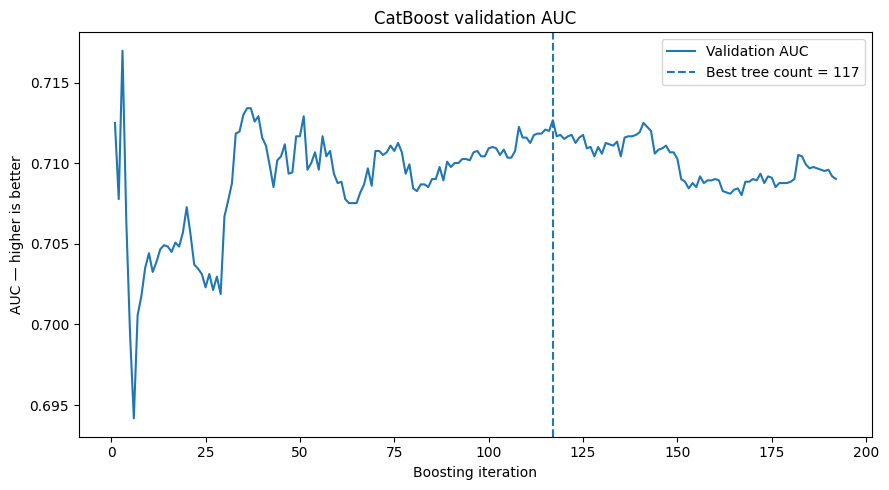

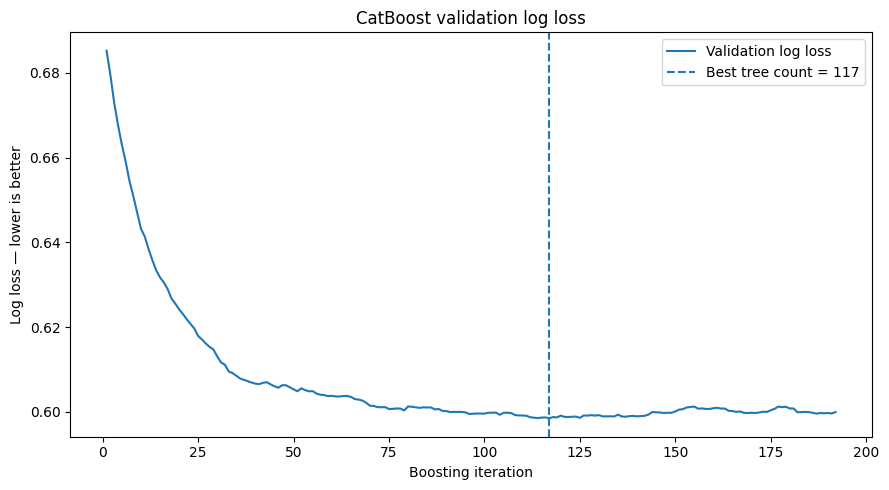

In [8]:
evaluation_history = candidate_model.get_evals_result()
validation_auc = evaluation_history['validation']['AUC']
validation_logloss = evaluation_history['validation']['Logloss']
rounds = np.arange(1, len(validation_auc) + 1)

plt.figure(figsize=(9, 5))
plt.plot(rounds, validation_auc, label='Validation AUC')
plt.axvline(best_tree_count, linestyle='--', label=f'Best tree count = {best_tree_count}')
plt.xlabel('Boosting iteration')
plt.ylabel('AUC — higher is better')
plt.title('CatBoost validation AUC')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(rounds, validation_logloss, label='Validation log loss')
plt.axvline(best_tree_count, linestyle='--', label=f'Best tree count = {best_tree_count}')
plt.xlabel('Boosting iteration')
plt.ylabel('Log loss — lower is better')
plt.title('CatBoost validation log loss')
plt.legend()
plt.tight_layout()
plt.show()

### Reading the graphs

- AUC measures ranking quality; higher is better.
- Log loss measures probability quality; lower is better.
- Early stopping follows the chosen `eval_metric`, which is log loss here.
- AUC is still recorded as an additional ranking metric, but it does not decide the stopping point.

## 11. A reusable evaluation function

In [9]:
def evaluate_classifier(model, X_eval, y_eval, set_name='Dataset'):
    """Print useful binary-classification metrics and draw two diagnostic plots."""
    predictions = model.predict(X_eval)
    probabilities = model.predict_proba(X_eval)[:, 1]

    metrics = pd.Series({
        'Accuracy': accuracy_score(y_eval, predictions),
        'Precision': precision_score(y_eval, predictions, zero_division=0),
        'Recall': recall_score(y_eval, predictions, zero_division=0),
        'F1 score': f1_score(y_eval, predictions, zero_division=0),
        'ROC AUC': roc_auc_score(y_eval, probabilities),
        'Log loss': log_loss(y_eval, probabilities),
    }, name=set_name)

    display(metrics.to_frame().round(4))
    print(classification_report(
        y_eval,
        predictions,
        target_names=class_names,
        zero_division=0,
    ))

    ConfusionMatrixDisplay.from_predictions(
        y_eval,
        predictions,
        display_labels=class_names,
    )
    plt.title(f'{set_name}: confusion matrix')
    plt.tight_layout()
    plt.show()

    RocCurveDisplay.from_predictions(y_eval, probabilities)
    plt.title(f'{set_name}: ROC curve')
    plt.tight_layout()
    plt.show()

    return metrics

### Metric meanings

| Metric | Simple meaning |
|---|---|
| **Accuracy** | Fraction of all predictions that are correct. |
| **Precision** | When churn is predicted, how often does churn occur? |
| **Recall** | Of all customers who churn, how many were detected? |
| **F1 score** | Balance between churn precision and churn recall. |
| **ROC AUC** | Ability to rank churners above non-churners across thresholds. |
| **Log loss** | Quality of predicted probabilities. Lower is better. |

## 12. Evaluate the early-stopped model on validation data

,Validation set
Accuracy,0.6800
Precision,0.6379
Recall,0.4205
F1 score,0.5068
ROC AUC,0.7127
Log loss,0.5985


              precision    recall  f1-score   support

       stays       0.69      0.85      0.76       137
      churns       0.64      0.42      0.51        88

    accuracy                           0.68       225
   macro avg       0.67      0.63      0.64       225
weighted avg       0.67      0.68      0.66       225



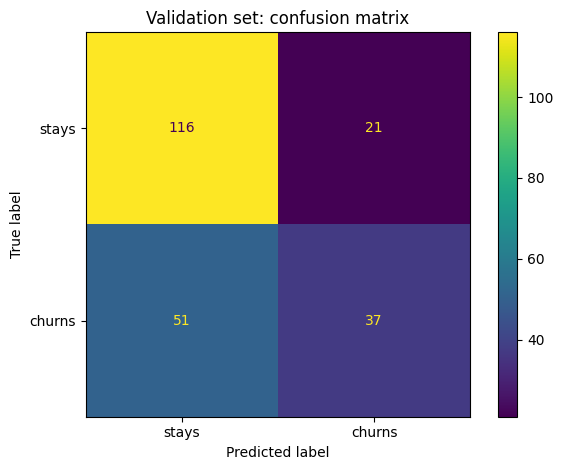

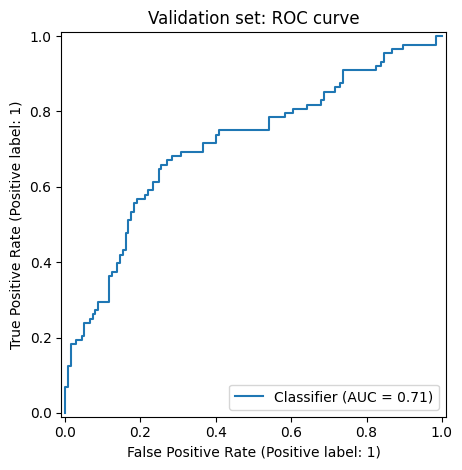

In [10]:
validation_metrics = evaluate_classifier(
    candidate_model,
    X_validation,
    y_validation,
    set_name='Validation set',
)

## 13. Retrain on training + validation data

The validation set selected the number of trees. We now train a fresh CatBoost model on all development rows with that exact tree count.

The test set remains untouched.

In [11]:
X_development = pd.concat([X_train, X_validation], axis=0)
y_development = pd.concat([y_train, y_validation], axis=0)

final_parameters = model_parameters.copy()
final_parameters['iterations'] = best_tree_count
# The final model is no longer choosing an iteration, so only the training objective is needed.
final_parameters.pop('eval_metric', None)
final_parameters.pop('custom_metric', None)

final_model = CatBoostClassifier(**final_parameters)
final_model.fit(
    X_development,
    y_development,
    cat_features=categorical_columns,
    verbose=False,
)

print('Development rows:', len(X_development))
print('Final tree count:', final_model.tree_count_)

Development rows: 1275
Final tree count: 117


## 14. Final evaluation on the untouched test set

,Untouched test set
Accuracy,0.7156
Precision,0.6769
Recall,0.5057
F1 score,0.5789
ROC AUC,0.7813
Log loss,0.5541


              precision    recall  f1-score   support

       stays       0.73      0.85      0.79       138
      churns       0.68      0.51      0.58        87

    accuracy                           0.72       225
   macro avg       0.70      0.68      0.68       225
weighted avg       0.71      0.72      0.71       225



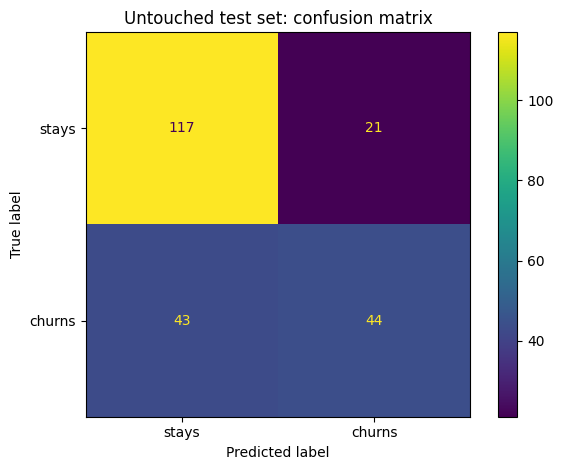

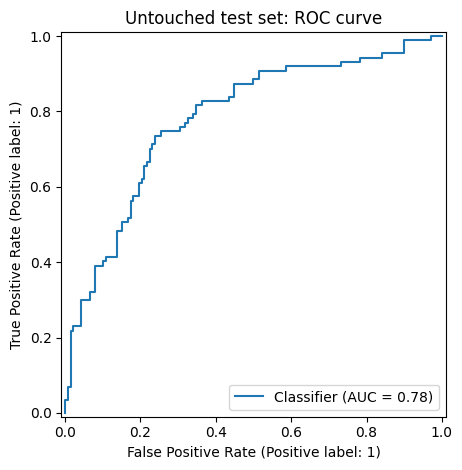

In [12]:
test_metrics = evaluate_classifier(
    final_model,
    X_test,
    y_test,
    set_name='Untouched test set',
)

The synthetic dataset's exact metrics are less important than the workflow: split first, tune with validation data, and use the test set only for the final estimate.

## 15. Inspect predicted probabilities

In [13]:
probability_examples = X_test.head(10).copy()
probability_examples['actual_class'] = y_test.head(10).map(dict(enumerate(class_names)))
probability_examples['predicted_class'] = pd.Series(
    final_model.predict(X_test.head(10)).astype(int).ravel(),
    index=X_test.head(10).index,
).map(dict(enumerate(class_names)))
probability_examples['churn_probability'] = final_model.predict_proba(X_test.head(10))[:, 1]

probability_examples[
    ['contract_type', 'support_plan', 'tenure_months', 'support_calls',
     'actual_class', 'predicted_class', 'churn_probability']
].round(4)

,contract_type,support_plan,tenure_months,support_calls,actual_class,predicted_class,churn_probability
1304,Month-to-month,Basic,50,0,churns,stays,0.4668
549,Month-to-month,None,50,1,stays,churns,0.5945
249,Month-to-month,Basic,31,1,churns,stays,0.4911
241,Month-to-month,None,24,0,stays,churns,0.5453
668,Month-to-month,None,25,0,churns,churns,0.6078
533,Month-to-month,None,53,0,stays,stays,0.4648
63,Two year,Basic,7,1,stays,stays,0.2319
1208,Month-to-month,None,17,2,churns,churns,0.7731
1129,Month-to-month,None,68,0,churns,churns,0.5520
1165,One year,Basic,6,1,churns,stays,0.3186


A business may choose a threshold other than `0.5`. For example, a retention team with spare capacity may use a lower threshold to identify more possible churners, accepting more false alarms.

## 16. Feature importance

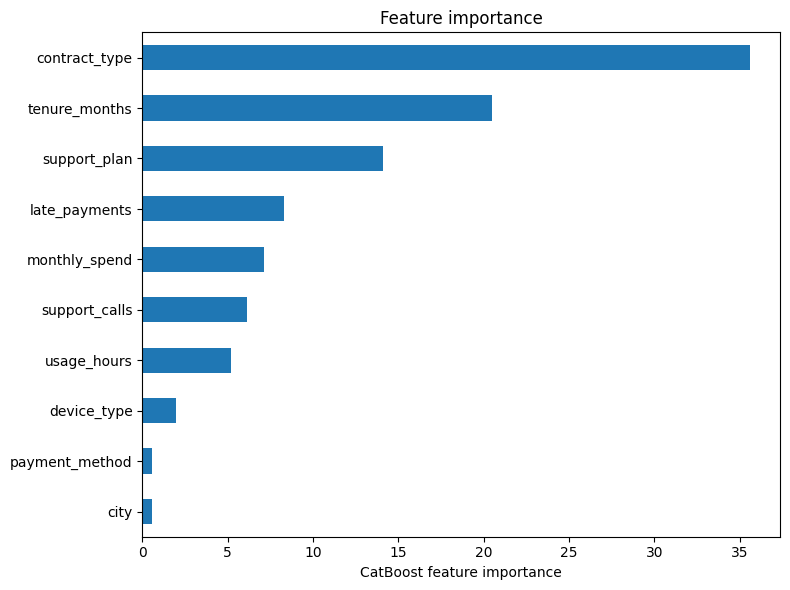

,importance
contract_type,35.574000
tenure_months,20.458285
support_plan,14.096363
late_payments,8.274808
monthly_spend,7.136275
support_calls,6.144011
usage_hours,5.205720
device_type,1.979391
payment_method,0.572684
city,0.558463


In [14]:
feature_importance = pd.Series(
    final_model.get_feature_importance(),
    index=X.columns,
    name='importance',
).sort_values(ascending=False)

feature_importance.sort_values().plot(kind='barh', figsize=(8, 6))
plt.xlabel('CatBoost feature importance')
plt.title('Feature importance')
plt.tight_layout()
plt.show()

feature_importance.to_frame()

CatBoost's default classification importance describes the average prediction change associated with features in the fitted model. It is not causal proof. Use SHAP values for a deeper local and global explanation workflow.

## 17. Common CatBoost parameters — simple reference

| Parameter | Simple meaning |
|---|---|
| `iterations` | Maximum number of boosting trees. |
| `learning_rate` | Contribution of each tree. |
| `depth` | Tree depth for the default symmetric-tree policy. |
| `loss_function` | Mathematical objective optimized during training. |
| `eval_metric` | Main validation metric used by early stopping. |
| `custom_metric` | Extra metrics calculated for monitoring. |
| `l2_leaf_reg` | L2 regularization on leaf values. |
| `random_strength` | Randomness used while scoring candidate splits. |
| `bagging_temperature` | Controls Bayesian bootstrap randomness; larger values produce more varied sampling. |
| `subsample` | Fraction of rows sampled when a compatible bootstrap type is used. |
| `border_count` | Number of bins used to convert continuous features into candidate split ranges. |
| `one_hot_max_size` | Small categorical features at or below this cardinality may use one-hot encoding internally. |
| `auto_class_weights` | Automatically balance classes, for example `'Balanced'`. |
| `class_weights` | Manually assign different importance to classes. |
| `random_seed` | Random seed. |
| `task_type` | `'CPU'` or `'GPU'`. |
| `thread_count` | Number of CPU threads. `-1` uses available cores. |
| `grow_policy` | Rule controlling how trees grow. |
| `allow_writing_files` | Controls whether CatBoost writes training files to disk. |

## 18. Parameters passed to `.fit()`

| Parameter | Simple meaning |
|---|---|
| `X` | Input feature table. |
| `y` | Target values. |
| `cat_features` | Categorical column names or indexes. |
| `eval_set` | Validation dataset. |
| `early_stopping_rounds` | Number of rounds to wait for improvement before stopping. |
| `use_best_model` | Keep only the best validation iteration. |
| `verbose` | Controls training messages. |

`cat_features` can also be specified in the constructor, but this notebook supplies it during fitting so the role is visible.

## 19. Optional CatBoost randomized search

In [15]:
# This cell is a reusable example and is not executed automatically.
# CatBoost's own randomized_search method understands categorical features.

# search_model = CatBoostClassifier(
#     loss_function='Logloss',
#     eval_metric='AUC',
#     cat_features=categorical_columns,
#     random_seed=RANDOM_STATE,
#     verbose=False,
#     allow_writing_files=False,
# )
#
# parameter_distributions = {
#     'iterations': [250, 500, 800],
#     'learning_rate': [0.02, 0.05, 0.1],
#     'depth': [4, 6, 8],
#     'l2_leaf_reg': [1, 3, 7, 12],
#     'random_strength': [0.0, 0.5, 1.0, 2.0],
# }
#
# search_result = search_model.randomized_search(
#     param_distributions=parameter_distributions,
#     X=X_development,
#     y=y_development,
#     cv=4,
#     n_iter=20,
#     partition_random_seed=RANDOM_STATE,
#     stratified=True,
#     verbose=False,
#     plot=False,
# )
#
# print(search_result['params'])

### Search parameters

| Parameter | Simple meaning |
|---|---|
| `param_distributions` | Possible values from which combinations are sampled. |
| `cv=4` | Use four cross-validation folds. |
| `n_iter=20` | Try 20 random combinations. |
| `partition_random_seed` | Makes the sampled combinations repeatable. |
| `stratified=True` | Keep class ratios approximately stable in every fold. |
| `plot=False` | Do not open CatBoost's interactive training plot. |

## 20. Save and reload the model

In [16]:
model_path = Path('catboost_customer_churn_model.cbm')
final_model.save_model(model_path)

reloaded_model = CatBoostClassifier()
reloaded_model.load_model(model_path)

original_predictions = final_model.predict(X_test).astype(int).ravel()
reloaded_predictions = reloaded_model.predict(X_test).astype(int).ravel()

print('Saved to:', model_path.resolve())
print('Reloaded predictions are identical:', np.array_equal(original_predictions, reloaded_predictions))

Saved to: /mnt/data/catboost_customer_churn_model.cbm
Reloaded predictions are identical: True


## 21. Practical tuning guide

| Situation | Parameters to inspect first |
|---|---|
| Model underfits | Increase `iterations`, increase `depth` carefully, or increase `learning_rate`. |
| Model overfits | Lower `depth`, increase `l2_leaf_reg`, reduce learning rate, add bagging randomness, or use earlier stopping. |
| Many categories | Keep raw categories, inspect cardinality, and compare `one_hot_max_size` only when needed. |
| Classes are imbalanced | Evaluate precision/recall and consider `auto_class_weights='Balanced'`. |
| Training is slow | Reduce iterations, use a larger learning rate cautiously, reduce depth, or evaluate GPU training. |
| Probabilities are poorly calibrated | Compare log loss and calibration methods; strong AUC alone does not guarantee good probabilities. |

## 22. Common mistakes

1. Converting category names to arbitrary integers and forgetting to mark them as categorical.
2. One-hot encoding everything before trying CatBoost's native handling.
3. Giving `cat_features` names that do not exactly match the DataFrame columns.
4. Allowing different category representations across train and inference data.
5. Using the test set for early stopping.
6. Comparing only accuracy on imbalanced churn data.
7. Forgetting that unseen real-world categories and data drift require monitoring.
8. Treating synthetic-data performance as a production expectation.

## 23. Exercises

1. Remove `cat_features` and observe the resulting error or preprocessing requirement.
2. Compare `depth=4`, `6`, and `8`.
3. Set `auto_class_weights='Balanced'` and compare churn recall.
4. Change `eval_metric` from AUC to Logloss.
5. Add another categorical feature such as `marketing_channel`.
6. Select a threshold that increases churn recall.
7. Use SHAP values to explain individual predictions.
8. Replace the generated data with your own CSV using the template below.

## 24. Template for your own CSV dataset

In [17]:
# df = pd.read_csv('your_data.csv')
# target_column = 'target'
# categorical_columns = ['city', 'product_type', 'payment_method']
#
# X = df.drop(columns=[target_column]).copy()
# y = df[target_column].copy()
#
# # CatBoost categorical values should be consistently represented.
# # Convert category columns to strings after handling missing values.
# for column in categorical_columns:
#     X[column] = X[column].fillna('__MISSING__').astype(str)
#
# X_train, X_temp, y_train, y_temp = train_test_split(
#     X, y,
#     test_size=0.30,
#     stratify=y,
#     random_state=RANDOM_STATE,
# )
# X_validation, X_test, y_validation, y_test = train_test_split(
#     X_temp, y_temp,
#     test_size=0.50,
#     stratify=y_temp,
#     random_state=RANDOM_STATE,
# )
#
# model = CatBoostClassifier(
#     iterations=1000,
#     learning_rate=0.05,
#     depth=6,
#     loss_function='Logloss',
#     eval_metric='AUC',
#     random_seed=RANDOM_STATE,
#     allow_writing_files=False,
# )
# model.fit(
#     X_train, y_train,
#     cat_features=categorical_columns,
#     eval_set=(X_validation, y_validation),
#     early_stopping_rounds=50,
#     use_best_model=True,
#     verbose=False,
# )

## 25. Final checklist

- [x] Numerical and categorical features
- [x] Separate training, validation, and test sets
- [x] Stratified splitting
- [x] Native categorical-feature handling
- [x] Numeric missing values
- [x] Every used model and fit parameter explained
- [x] Validation-based early stopping
- [x] Final retraining using the selected tree count
- [x] Test set evaluated once
- [x] Multiple classification metrics
- [x] Learning curves
- [x] Feature importance
- [x] Optional randomized search
- [x] Native CatBoost model saving and reloading

### Official documentation

- [CatBoostClassifier](https://catboost.ai/docs/en/concepts/python-reference_catboostclassifier)
- [CatBoost training parameters](https://catboost.ai/docs/en/references/training-parameters/)
- [CatBoost overfitting detector](https://catboost.ai/docs/en/features/overfitting-detector-desc)